# Skip-gram with Negative Sampling on `text8`

This notebook implements and analyzes **Skip-gram with Negative Sampling (SGNS)** using the `text8` corpus. The workflow covers corpus preparation, vocabulary construction, center-context pair generation, negative sampling, neural training, embedding extraction, semantic evaluation, and geometric analysis.

The executable code is preserved while the surrounding documentation and code comments are provided in English.

In [ ]:
!pip -q install tqdm

import os
import re
import math
import zipfile
import random
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

## Google Drive setup

Google Drive is mounted so that the corpus, trained embeddings, intermediate files, and analysis outputs can persist across Colab sessions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Project directories

The project and data directories are created inside Google Drive. Centralizing paths in `Path` objects makes the notebook easier to adapt and keeps generated artifacts organized.

In [ ]:
from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/SGNS_Wikipedia")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

print(DRIVE_DIR)

/content/drive/MyDrive/SGNS_Wikipedia


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/SGNS_Wikipedia/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## Downloading the `text8` corpus

The notebook downloads `text8`, a cleaned English-language corpus commonly used for word-embedding experiments. The ZIP file is downloaded only when it is not already available in the configured data directory.

In [ ]:
url = "https://mattmahoney.net/dc/text8.zip"
zip_path = DATA_DIR / "text8.zip"

if not zip_path.exists():
    print("Descargando corpus text8 en Drive...")
    urllib.request.urlretrieve(url, zip_path)
else:
    print("El corpus ya existe en Drive.")

El corpus ya existe en Drive.


## Loading and inspecting the corpus

The compressed corpus is read directly from the ZIP archive, decoded as UTF-8, and split on whitespace. A small sample is displayed to verify that the corpus was loaded correctly.

In [ ]:
with zipfile.ZipFile(zip_path, "r") as z:
    text = z.read("text8").decode("utf-8")

tokens = text.split()

print("Número total de tokens:", len(tokens))
print(tokens[:20])

Número total de tokens: 17005207
['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']


In [ ]:
print(text[:2000])

 anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english revolution and the sans culottes of the french revolution whilst the term is still used in a pejorative way to describe any act that used violent means to destroy the organization of society it has also been taken up as a positive label by self defined anarchists the word anarchism is derived from the greek without archons ruler chief king anarchism as a political philosophy is the belief that rulers are unnecessary and should be abolished although there are differing interpretations of what this means anarchism also refers to related social movements that advocate the elimination of authoritarian institutions particularly the state the word anarchy as most anarchists use it does not imply chaos nihilism or anomie but rather a harmonious anti authoritarian society in place of what are regarded as authoritarian political structures and coercive economic instituti

## Limiting the training corpus

To keep the experiment computationally manageable, only the first `MAX_TOKENS` tokens are retained. Increasing this value may improve embedding quality but also increases pair generation time and memory usage.

In [ ]:
MAX_TOKENS = 5_000_000
tokens = tokens[:MAX_TOKENS]

print("Tokens usados:", len(tokens))

Tokens usados: 5000000


## Vocabulary construction

The vocabulary is built from the most frequent tokens in the corpus. Two filters are applied:

- `min_count = 5` removes words that occur fewer than five times.
- `max_vocab_size = 50_000` limits the vocabulary to the 50,000 most frequent eligible words.

The dictionaries `stoi` and `itos` provide the mappings from words to integer indices and from indices back to words. These mappings are required because the neural model operates on integer identifiers rather than raw strings.

In [ ]:
min_count = 5
max_vocab_size = 50_000

counter = Counter(tokens)

vocab_words = [
    word for word, count in counter.most_common(max_vocab_size)
    if count >= min_count
]

stoi = {word: idx for idx, word in enumerate(vocab_words)}
itos = {idx: word for word, idx in stoi.items()}

vocab_size = len(stoi)

print("Tamaño del vocabulario:", vocab_size)
print(vocab_words[:20])

Tamaño del vocabulario: 36280
['the', 'of', 'and', 'one', 'in', 'a', 'to', 'zero', 'nine', 'two', 'is', 'as', 'eight', 'for', 'five', 'three', 'by', 's', 'was', 'that']


## Corpus indexing

The textual corpus is converted into a sequence of integer identifiers using the vocabulary mapping:

```python
ids = [stoi[w] for w in tokens if w in stoi]
```

Words outside the selected vocabulary are discarded. The resulting NumPy array represents the complete training corpus in a compact numerical format that can be used to generate center-context pairs.

In [ ]:
ids = [stoi[w] for w in tokens if w in stoi]
ids = np.array(ids, dtype=np.int64)

print("Longitud del corpus indexado:", len(ids))
print(ids[:20])

Longitud del corpus indexado: 4859031
[ 3137  3013    11     5   180     1  4220    48    57   149   123   841
   494  8220   131     0 32352     1     0   113]


## Noise distribution for negative sampling

SGNS avoids computing a full softmax over the vocabulary. Instead, each observed center-context pair is contrasted with several negative contexts sampled from a noise distribution.

Following the standard SGNS formulation, the unigram frequencies are raised to the power \(0.75\):

\[
P_n(w)=\frac{f(w)^{0.75}}{\sum_{w' \in V} f(w')^{0.75}}.
\]

This transformation reduces the dominance of extremely frequent words while preserving enough frequency information to produce plausible negative examples.

In [ ]:
word_counts = np.array([counter[itos[i]] for i in range(vocab_size)], dtype=np.float64)

noise_dist = word_counts ** 0.75
noise_dist = noise_dist / noise_dist.sum()

noise_dist = torch.tensor(noise_dist, dtype=torch.float32)

print(noise_dist[:10])
print("Suma:", noise_dist.sum().item())

tensor([0.0162, 0.0105, 0.0080, 0.0075, 0.0073, 0.0066, 0.0064, 0.0055, 0.0050,
        0.0044])
Suma: 0.9999999403953552


## Frequent-word subsampling

Very frequent words may dominate training while contributing limited semantic information. The following function probabilistically removes a portion of those tokens before the training pairs are created.

Subsampling reduces the size of the effective corpus, accelerates training, and gives relatively more importance to less frequent and potentially more informative words. A fixed random seed is used to make the operation reproducible.

In [ ]:
def subsample_frequent_words(ids, word_counts, threshold=1e-5, seed=42):
    rng = np.random.default_rng(seed)

    total_count = word_counts.sum()
    freqs = word_counts / total_count

    # Approximate probability of keeping a word
    keep_probs = (np.sqrt(freqs / threshold) + 1) * (threshold / freqs)
    keep_probs = np.minimum(keep_probs, 1.0)

    mask = rng.random(len(ids)) < keep_probs[ids]
    return ids[mask]

use_subsampling = True

if use_subsampling:
    ids_train = subsample_frequent_words(ids, word_counts, threshold=1e-5)
else:
    ids_train = ids

print("Longitud antes:", len(ids))
print("Longitud después:", len(ids_train))

Longitud antes: 4859031
Longitud después: 1554545


## Positive Skip-gram pair generation

Each positive training example consists of a center word and one of its surrounding context words:

\[
(w_t, w_{t+j}), \qquad -c \leq j \leq c,\quad j\neq 0.
\]

A dynamic context window is sampled between 1 and `window_size`. This introduces variability into the contexts observed during training. The number of generated pairs is capped to control memory usage and execution time.

In [ ]:
def generate_skipgram_pairs(ids, window_size=5, max_pairs=5_000_000, seed=42):
    rng = random.Random(seed)

    centers = []
    contexts = []

    n = len(ids)

    for t in tqdm(range(n), desc="Generando pares positivos"):
        center = ids[t]

        # Dynamic window: between 1 and window_size
        current_window = rng.randint(1, window_size)

        start = max(0, t - current_window)
        end = min(n, t + current_window + 1)

        for j in range(start, end):
            if j != t:
                centers.append(center)
                contexts.append(ids[j])

                if len(centers) >= max_pairs:
                    return (
                        np.array(centers, dtype=np.int64),
                        np.array(contexts, dtype=np.int64)
                    )

    return (
        np.array(centers, dtype=np.int64),
        np.array(contexts, dtype=np.int64)
    )

window_size = 5
max_pairs = 3_000_000

centers, contexts = generate_skipgram_pairs(
    ids_train,
    window_size=window_size,
    max_pairs=max_pairs
)

print("Número de pares positivos:", len(centers))
print(centers[:10])
print(contexts[:10])

Generando pares positivos:   0%|          | 0/1554545 [00:00<?, ?it/s]

Número de pares positivos: 3000000
[3137 3013 3013  180  180  180  180  180 4220 4220]
[ 3013  3137   180  3137  3013  4220  8220 32352  3013   180]


## TensorFlow training stage

The previous cells prepare the indexed corpus and positive Skip-gram pairs. The following section switches to TensorFlow/Keras to define, train, and evaluate the neural SGNS model.

In [ ]:
import tensorflow as tf
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

## Training and validation split

The generated positive pairs are shuffled and divided into training and validation subsets. The validation set is used to monitor whether the model generalizes beyond the pairs used to update its parameters.

In [ ]:
num_pairs = len(centers)

indices = np.arange(num_pairs)
np.random.shuffle(indices)

val_fraction = 0.05
val_size = int(num_pairs * val_fraction)

val_idx = indices[:val_size]
train_idx = indices[val_size:]

centers_train = centers[train_idx]
contexts_train = contexts[train_idx]

centers_val = centers[val_idx]
contexts_val = contexts[val_idx]

print("Pares entrenamiento:", len(centers_train))
print("Pares validación:", len(centers_val))

Pares entrenamiento: 2850000
Pares validación: 150000


## TensorFlow noise distribution

The negative-sampling distribution is converted to a TensorFlow tensor. Its logarithm is also precomputed for formulations that use noise-adjusted logits or related diagnostic calculations.

In [ ]:
noise_dist_tf = word_counts.astype(np.float64) ** 0.75
noise_dist_tf = noise_dist_tf / noise_dist_tf.sum()

noise_dist_tf = tf.constant(noise_dist_tf, dtype=tf.float32)

log_noise_dist = tf.math.log(tf.reshape(noise_dist_tf, [1, -1]))

print("Suma distribución de ruido:", tf.reduce_sum(noise_dist_tf).numpy())
print("Forma:", noise_dist_tf.shape)

Suma distribución de ruido: 1.0
Forma: (36280,)


## Direct SGNS model

The `SGNS` class explicitly stores two embedding matrices:

- \(E\): center-word embeddings;
- \(U\): context-word embeddings.

For each batch, the model computes the score of the observed center-context pair and the scores of sampled negative contexts. The objective encourages positive dot products to increase and negative dot products to decrease.

In [ ]:
import tensorflow as tf

class SGNS(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        # Matrix E: input/center-word embeddings
        self.center_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.RandomUniform(
                minval=-0.5 / embedding_dim,
                maxval=0.5 / embedding_dim
            ),
            name="E_center_embeddings"
        )

        # Matrix U: context/output embeddings
        self.context_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer="zeros",
            name="U_context_embeddings"
        )

    def call(self, center_words, positive_contexts, negative_contexts):
        """
        center_words:      tensor with shape [B]
        positive_contexts: tensor with shape [B]
        negative_contexts: tensor with shape [B, S]
        """

        # v_w: [B, d]
        v_center = self.center_embedding(center_words)

        # u_o: [B, d]
        u_pos = self.context_embedding(positive_contexts)

        # u_neg: [B, S, d]
        u_neg = self.context_embedding(negative_contexts)

        # Positive dot product: u_o^T v_w
        # Resulting shape: [B]
        pos_score = tf.reduce_sum(v_center * u_pos, axis=1)

        # Negative dot products: u_s^T v_w
        # v_center: [B, d] -> [B, 1, d]
        # u_neg:    [B, S, d]
        # result: [B, S]
        neg_score = tf.reduce_sum(
            u_neg * tf.expand_dims(v_center, axis=1),
            axis=2
        )

        return pos_score, neg_score

In [ ]:
import tensorflow as tf

class SGNS(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        # Matrix E: input/center-word embeddings
        self.center_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.RandomUniform(
                minval=-0.5 / embedding_dim,
                maxval=0.5 / embedding_dim
            ),
            name="E_center_embeddings"
        )

        # Matrix U: context/output embeddings
        self.context_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer="zeros",
            name="U_context_embeddings"
        )

    def call(self, center_words, positive_contexts, negative_contexts):
        """
        center_words:      tensor with shape [B]
        positive_contexts: tensor with shape [B]
        negative_contexts: tensor with shape [B, S]
        """

        # v_w: [B, d]
        v_center = self.center_embedding(center_words)

        # u_o: [B, d]
        u_pos = self.context_embedding(positive_contexts)

        # u_neg: [B, S, d]
        u_neg = self.context_embedding(negative_contexts)

        # Positive dot product: u_o^T v_w
        # Resulting shape: [B]
        pos_score = tf.reduce_sum(v_center * u_pos, axis=1)

        # Negative dot products: u_s^T v_w
        # v_center: [B, d] -> [B, 1, d]
        # u_neg:    [B, S, d]
        # result: [B, S]
        neg_score = tf.reduce_sum(
            u_neg * tf.expand_dims(v_center, axis=1),
            axis=2
        )

        return pos_score, neg_score

## Binary Skip-gram layer

This alternative formulation treats SGNS as binary classification. Each input contains a center word and a context word, while the target indicates whether the pair is observed (`1`) or sampled as a negative example (`0`).

In [ ]:
import tensorflow as tf

class SkipGramBinaryLayer(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.center_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.RandomUniform(
                minval=-0.5 / embedding_dim,
                maxval=0.5 / embedding_dim
            ),
            name="E_center_embeddings"
        )

        self.context_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer="zeros",
            name="U_context_embeddings"
        )

    def call(self, inputs):
        # inputs has shape [B, 2]
        # inputs[:, 0] = center word
        # inputs[:, 1] = positive or negative context word

        center_words = inputs[:, 0]
        context_words = inputs[:, 1]

        v_center = self.center_embedding(center_words)   # [B, d]
        u_context = self.context_embedding(context_words) # [B, d]

        score = tf.reduce_sum(v_center * u_context, axis=1) # [B]

        prob = tf.sigmoid(score)

        return prob

## Model construction and compilation

A Keras `Sequential` model wraps the custom binary Skip-gram layer. The model uses 100-dimensional embeddings, the Adam optimizer, binary cross-entropy, and accuracy as a monitoring metric.

In [ ]:
embedding_dim = 100

model_sgns_seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,), dtype=tf.int64),
    SkipGramBinaryLayer(vocab_size, embedding_dim)
])

model_sgns_seq.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model_sgns_seq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skip_gram_binary_layer          │ (None)                 │     7,256,000 │
│ (SkipGramBinaryLayer)           │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,256,000 (27.68 MB)

 Trainable params: 7,256,000 (27.68 MB)

 Non-trainable params: 0 (0.00 B)

## Creating positive and negative examples

Observed center-context pairs receive label `1`. For every positive pair, several negative contexts are sampled from the noise distribution and receive label `0`. Positive and negative examples are then concatenated and shuffled.

In [ ]:
num_negative = 5

def create_binary_skipgram_dataset(centers, contexts, noise_dist, num_negative=5):
    n = len(centers)

    # Positive pairs
    positive_pairs = np.stack([centers, contexts], axis=1)
    positive_labels = np.ones(n, dtype=np.float32)

    # Negative pairs
    negative_centers = np.repeat(centers, num_negative)

    negative_contexts = np.random.choice(
        np.arange(vocab_size),
        size=n * num_negative,
        replace=True,
        p=noise_dist.numpy() if hasattr(noise_dist, "numpy") else noise_dist
    )

    negative_pairs = np.stack([negative_centers, negative_contexts], axis=1)
    negative_labels = np.zeros(n * num_negative, dtype=np.float32)

    # Combine positive and negative examples
    X = np.concatenate([positive_pairs, negative_pairs], axis=0)
    y = np.concatenate([positive_labels, negative_labels], axis=0)

    # Shuffle
    idx = np.random.permutation(len(X))
    X = X[idx]
    y = y[idx]

    return X.astype(np.int64), y.astype(np.float32)

In [ ]:
X_train, y_train = create_binary_skipgram_dataset(
    centers_train,
    contexts_train,
    noise_dist,
    num_negative=5
)

X_val, y_val = create_binary_skipgram_dataset(
    centers_val,
    contexts_val,
    noise_dist,
    num_negative=5
)

print(X_train.shape)
print(y_train.shape)

(17100000, 2)
(17100000,)


## SGNS training

The model is trained for three epochs with a large batch size. Validation data are supplied to monitor the binary objective on held-out center-context pairs.

In [ ]:
history = model_sgns_seq.fit(
    X_train,
    y_train,
    batch_size=2048,
    epochs=3,
    validation_data=(X_val, y_val)
)

Epoch 1/3
8350/8350 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.0014 - loss: 0.4395 - val_accuracy: 0.0023 - val_loss: 0.4185
Epoch 2/3
8350/8350 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.0024 - loss: 0.4026 - val_accuracy: 0.0023 - val_loss: 0.3841
Epoch 3/3
8350/8350 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.0031 - loss: 0.3601 - val_accuracy: 0.0045 - val_loss: 0.3560


## Extracting the learned embeddings

After training, the center-word matrix \(E\) and context matrix \(U\) are extracted from the custom layer. The center-word embeddings are subsequently normalized so cosine similarity can be computed with a dot product.

In [ ]:
sg_layer = model_sgns_seq.layers[0]

E_embeddings = sg_layer.center_embedding.get_weights()[0]
U_embeddings = sg_layer.context_embedding.get_weights()[0]

print("Forma de E:", E_embeddings.shape)
print("Forma de U:", U_embeddings.shape)

Forma de E: (36280, 100)
Forma de U: (36280, 100)


In [ ]:
import numpy as np

E_norm = E_embeddings / np.linalg.norm(
    E_embeddings,
    axis=1,
    keepdims=True
)

## Nearest-neighbor evaluation

Nearest neighbors provide a qualitative assessment of the learned semantic space. For a query word, cosine similarity is computed against the full normalized vocabulary, and the most similar words are returned.

In [ ]:
def nearest_neighbors(word, k=10):
    if word not in stoi:
        print(f"La palabra '{word}' no está en el vocabulario.")
        return []

    idx = stoi[word]
    vector = E_norm[idx]

    similarities = E_norm @ vector

    nearest_ids = np.argsort(-similarities)

    results = []

    for neighbor_idx in nearest_ids:
        if neighbor_idx == idx:
            continue

        results.append(
            (itos[neighbor_idx], float(similarities[neighbor_idx]))
        )

        if len(results) == k:
            break

    return results

In [ ]:
nearest_neighbors("king", k=10)

[('navarre', 0.906683623790741),
 ('iv', 0.887398362159729),
 ('aquitaine', 0.8798414468765259),
 ('son', 0.8764578104019165),
 ('epirus', 0.8758612275123596),
 ('rehoboam', 0.8740658760070801),
 ('sancho', 0.8737969398498535),
 ('moors', 0.8691908717155457),
 ('throne', 0.8648520112037659),
 ('ducas', 0.8645063638687134)]

In [ ]:
nearest_neighbors("music", k=10)

[('unicef', 0.8189579248428345),
 ('nightclubs', 0.8079861402511597),
 ('dad', 0.8013738393783569),
 ('barbera', 0.8013637065887451),
 ('concert', 0.8003214001655579),
 ('disney', 0.7944268584251404),
 ('dvd', 0.7882510423660278),
 ('slapstick', 0.7857757806777954),
 ('vhs', 0.7852228879928589),
 ('sinfonia', 0.7779362797737122)]

In [ ]:
nearest_neighbors("computer", k=10)

[('amigaone', 0.8745086193084717),
 ('visicalc', 0.871810793876648),
 ('innovative', 0.8697829842567444),
 ('graphical', 0.8684709668159485),
 ('powerpc', 0.8625446557998657),
 ('machines', 0.8616371154785156),
 ('portable', 0.8612353801727295),
 ('amigaos', 0.8522300124168396),
 ('microsoft', 0.8502922654151917),
 ('video', 0.8488047122955322)]

In [ ]:
nearest_neighbors("city", k=10)

[('subway', 0.8205716609954834),
 ('belize', 0.8061514496803284),
 ('towns', 0.8047193288803101),
 ('greyhound', 0.8023399114608765),
 ('mall', 0.7985353469848633),
 ('washtenaw', 0.7950551509857178),
 ('metropolitan', 0.7937707304954529),
 ('hectares', 0.7894725799560547),
 ('eastwards', 0.7894032597541809),
 ('tillotson', 0.7866320610046387)]

## Pairwise word similarity

The helper function below computes cosine similarity between two selected words. It also verifies that both words are present in the learned vocabulary.

In [ ]:
def cosine_similarity_words(word1, word2):
    if word1 not in stoi:
        print(f"La palabra '{word1}' no está en el vocabulario.")
        return None

    if word2 not in stoi:
        print(f"La palabra '{word2}' no está en el vocabulario.")
        return None

    idx1 = stoi[word1]
    idx2 = stoi[word2]

    sim = np.dot(E_norm[idx1], E_norm[idx2])

    return float(sim)

In [ ]:
cosine_similarity_words("king", "queen")

0.7957913875579834

In [ ]:
cosine_similarity_words("music", "song")

0.6458010077476501

In [ ]:
cosine_similarity_words("king", "car")

0.2928842306137085

## Consolidated end-to-end training script

The following cell combines the main preparation and training steps into a single executable script. It is useful for reproducing the complete SGNS workflow in a fresh Google Colab session without executing the preceding cells individually.

# Complete SGNS training pipeline

This cell reproduces the full workflow in a single block: environment setup, corpus preparation, vocabulary construction, pair generation, model training, and embedding extraction. It can be run independently when a compact end-to-end version is preferred.

In [ ]:
!pip -q install tqdm

import os
import re
import math
import zipfile
import random
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/SGNS_Wikipedia")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

print(DRIVE_DIR)
DATA_DIR = Path("/content/drive/MyDrive/SGNS_Wikipedia/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
url = "https://mattmahoney.net/dc/text8.zip"
zip_path = DATA_DIR / "text8.zip"

if not zip_path.exists():
    print("Descargando corpus text8 en Drive...")
    urllib.request.urlretrieve(url, zip_path)
else:
    print("El corpus ya existe en Drive.")
with zipfile.ZipFile(zip_path, "r") as z:
    text = z.read("text8").decode("utf-8")

tokens = text.split()

print("Número total de tokens:", len(tokens))
print(tokens[:20])

print(text[:2000])
MAX_TOKENS = 5_000_000
tokens = tokens[:MAX_TOKENS]

print("Tokens usados:", len(tokens))

min_count = 5
max_vocab_size = 50_000

counter = Counter(tokens)

vocab_words = [
    word for word, count in counter.most_common(max_vocab_size)
    if count >= min_count
]

stoi = {word: idx for idx, word in enumerate(vocab_words)}
itos = {idx: word for word, idx in stoi.items()}

vocab_size = len(stoi)

print("Tamaño del vocabulario:", vocab_size)
print(vocab_words[:20])
ids = [stoi[w] for w in tokens if w in stoi]
ids = np.array(ids, dtype=np.int64)

print("Longitud del corpus indexado:", len(ids))
print(ids[:20])
word_counts = np.array([counter[itos[i]] for i in range(vocab_size)], dtype=np.float64)

noise_dist = word_counts ** 0.75
noise_dist = noise_dist / noise_dist.sum()

noise_dist = torch.tensor(noise_dist, dtype=torch.float32)

print(noise_dist[:10])
print("Suma:", noise_dist.sum().item())
def subsample_frequent_words(ids, word_counts, threshold=1e-5, seed=42):
    rng = np.random.default_rng(seed)

    total_count = word_counts.sum()
    freqs = word_counts / total_count

    # Approximate probability of keeping a word
    keep_probs = (np.sqrt(freqs / threshold) + 1) * (threshold / freqs)
    keep_probs = np.minimum(keep_probs, 1.0)

    mask = rng.random(len(ids)) < keep_probs[ids]
    return ids[mask]

use_subsampling = True

if use_subsampling:
    ids_train = subsample_frequent_words(ids, word_counts, threshold=1e-5)
else:
    ids_train = ids

print("Longitud antes:", len(ids))
print("Longitud después:", len(ids_train))
def generate_skipgram_pairs(ids, window_size=5, max_pairs=5_000_000, seed=42):
    rng = random.Random(seed)

    centers = []
    contexts = []

    n = len(ids)

    for t in tqdm(range(n), desc="Generando pares positivos"):
        center = ids[t]

        # Dynamic window: between 1 and window_size
        current_window = rng.randint(1, window_size)

        start = max(0, t - current_window)
        end = min(n, t + current_window + 1)

        for j in range(start, end):
            if j != t:
                centers.append(center)
                contexts.append(ids[j])

                if len(centers) >= max_pairs:
                    return (
                        np.array(centers, dtype=np.int64),
                        np.array(contexts, dtype=np.int64)
                    )

    return (
        np.array(centers, dtype=np.int64),
        np.array(contexts, dtype=np.int64)
    )

window_size = 5
max_pairs = 3_000_000

centers, contexts = generate_skipgram_pairs(
    ids_train,
    window_size=window_size,
    max_pairs=max_pairs
)

print("Número de pares positivos:", len(centers))
print(centers[:10])
print(contexts[:10])
import tensorflow as tf
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

num_pairs = len(centers)

indices = np.arange(num_pairs)
np.random.shuffle(indices)

val_fraction = 0.05
val_size = int(num_pairs * val_fraction)

val_idx = indices[:val_size]
train_idx = indices[val_size:]

centers_train = centers[train_idx]
contexts_train = contexts[train_idx]

centers_val = centers[val_idx]
contexts_val = contexts[val_idx]

print("Pares entrenamiento:", len(centers_train))
print("Pares validación:", len(centers_val))

noise_dist_tf = word_counts.astype(np.float64) ** 0.75
noise_dist_tf = noise_dist_tf / noise_dist_tf.sum()

noise_dist_tf = tf.constant(noise_dist_tf, dtype=tf.float32)

log_noise_dist = tf.math.log(tf.reshape(noise_dist_tf, [1, -1]))

print("Suma distribución de ruido:", tf.reduce_sum(noise_dist_tf).numpy())
print("Forma:", noise_dist_tf.shape)

import tensorflow as tf

class SGNS(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        # Matrix E: input/center-word embeddings
        self.center_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.RandomUniform(
                minval=-0.5 / embedding_dim,
                maxval=0.5 / embedding_dim
            ),
            name="E_center_embeddings"
        )

        # Matrix U: context/output embeddings
        self.context_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer="zeros",
            name="U_context_embeddings"
        )

    def call(self, center_words, positive_contexts, negative_contexts):
        """
        center_words:      tensor with shape [B]
        positive_contexts: tensor with shape [B]
        negative_contexts: tensor with shape [B, S]
        """

        # v_w: [B, d]
        v_center = self.center_embedding(center_words)

        # u_o: [B, d]
        u_pos = self.context_embedding(positive_contexts)

        # u_neg: [B, S, d]
        u_neg = self.context_embedding(negative_contexts)

        # Positive dot product: u_o^T v_w
        # Resulting shape: [B]
        pos_score = tf.reduce_sum(v_center * u_pos, axis=1)

        # Negative dot products: u_s^T v_w
        # v_center: [B, d] -> [B, 1, d]
        # u_neg:    [B, S, d]
        # result: [B, S]
        neg_score = tf.reduce_sum(
            u_neg * tf.expand_dims(v_center, axis=1),
            axis=2
        )

        return pos_score, neg_score
import tensorflow as tf

class SGNS(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        # Matrix E: input/center-word embeddings
        self.center_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.RandomUniform(
                minval=-0.5 / embedding_dim,
                maxval=0.5 / embedding_dim
            ),
            name="E_center_embeddings"
        )

        # Matrix U: context/output embeddings
        self.context_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer="zeros",
            name="U_context_embeddings"
        )

    def call(self, center_words, positive_contexts, negative_contexts):
        """
        center_words:      tensor with shape [B]
        positive_contexts: tensor with shape [B]
        negative_contexts: tensor with shape [B, S]
        """

        # v_w: [B, d]
        v_center = self.center_embedding(center_words)

        # u_o: [B, d]
        u_pos = self.context_embedding(positive_contexts)

        # u_neg: [B, S, d]
        u_neg = self.context_embedding(negative_contexts)

        # Positive dot product: u_o^T v_w
        # Resulting shape: [B]
        pos_score = tf.reduce_sum(v_center * u_pos, axis=1)

        # Negative dot products: u_s^T v_w
        # v_center: [B, d] -> [B, 1, d]
        # u_neg:    [B, S, d]
        # result: [B, S]
        neg_score = tf.reduce_sum(
            u_neg * tf.expand_dims(v_center, axis=1),
            axis=2
        )

        return pos_score, neg_score
import tensorflow as tf

class SkipGramBinaryLayer(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.center_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.RandomUniform(
                minval=-0.5 / embedding_dim,
                maxval=0.5 / embedding_dim
            ),
            name="E_center_embeddings"
        )

        self.context_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer="zeros",
            name="U_context_embeddings"
        )

    def call(self, inputs):
        # inputs has shape [B, 2]
        # inputs[:, 0] = center word
        # inputs[:, 1] = positive or negative context word

        center_words = inputs[:, 0]
        context_words = inputs[:, 1]

        v_center = self.center_embedding(center_words)   # [B, d]
        u_context = self.context_embedding(context_words) # [B, d]

        score = tf.reduce_sum(v_center * u_context, axis=1) # [B]

        prob = tf.sigmoid(score)

        return prob
embedding_dim = 100

model_sgns_seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,), dtype=tf.int64),
    SkipGramBinaryLayer(vocab_size, embedding_dim)
])

model_sgns_seq.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
num_negative = 5

def create_binary_skipgram_dataset(centers, contexts, noise_dist, num_negative=5):
    n = len(centers)

    # Positive pairs
    positive_pairs = np.stack([centers, contexts], axis=1)
    positive_labels = np.ones(n, dtype=np.float32)

    # Negative pairs
    negative_centers = np.repeat(centers, num_negative)

    negative_contexts = np.random.choice(
        np.arange(vocab_size),
        size=n * num_negative,
        replace=True,
        p=noise_dist.numpy() if hasattr(noise_dist, "numpy") else noise_dist
    )

    negative_pairs = np.stack([negative_centers, negative_contexts], axis=1)
    negative_labels = np.zeros(n * num_negative, dtype=np.float32)

    # Combine positive and negative examples
    X = np.concatenate([positive_pairs, negative_pairs], axis=0)
    y = np.concatenate([positive_labels, negative_labels], axis=0)

    # Shuffle
    idx = np.random.permutation(len(X))
    X = X[idx]
    y = y[idx]

    return X.astype(np.int64), y.astype(np.float32)
X_train, y_train = create_binary_skipgram_dataset(
    centers_train,
    contexts_train,
    noise_dist,
    num_negative=5
)

X_val, y_val = create_binary_skipgram_dataset(
    centers_val,
    contexts_val,
    noise_dist,
    num_negative=5
)

print(X_train.shape)
print(y_train.shape)
history = model_sgns_seq.fit(
    X_train,
    y_train,
    batch_size=2048,
    epochs=3,
    validation_data=(X_val, y_val)
)
sg_layer = model_sgns_seq.layers[0]

E_embeddings = sg_layer.center_embedding.get_weights()[0]
U_embeddings = sg_layer.context_embedding.get_weights()[0]

print("Forma de E:", E_embeddings.shape)
print("Forma de U:", U_embeddings.shape)
import numpy as np

E_norm = E_embeddings / np.linalg.norm(
    E_embeddings,
    axis=1,
    keepdims=True
)
def nearest_neighbors(word, k=10):
    if word not in stoi:
        print(f"La palabra '{word}' no está en el vocabulario.")
        return []

    idx = stoi[word]
    vector = E_norm[idx]

    similarities = E_norm @ vector

    nearest_ids = np.argsort(-similarities)

    results = []

    for neighbor_idx in nearest_ids:
        if neighbor_idx == idx:
            continue

        results.append(
            (itos[neighbor_idx], float(similarities[neighbor_idx]))
        )

        if len(results) == k:
            break

    return results
def cosine_similarity_words(word1, word2):
    if word1 not in stoi:
        print(f"La palabra '{word1}' no está en el vocabulario.")
        return None

    if word2 not in stoi:
        print(f"La palabra '{word2}' no está en el vocabulario.")
        return None

    idx1 = stoi[word1]
    idx2 = stoi[word2]

    sim = np.dot(E_norm[idx1], E_norm[idx2])

    return float(sim)

Mounted at /content/drive
/content/drive/MyDrive/SGNS_Wikipedia
El corpus ya existe en Drive.
Número total de tokens: 17005207
['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']
 anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english revolution and the sans culottes of the french revolution whilst the term is still used in a pejorative way to describe any act that used violent means to destroy the organization of society it has also been taken up as a positive label by self defined anarchists the word anarchism is derived from the greek without archons ruler chief king anarchism as a political philosophy is the belief that rulers are unnecessary and should be abolished although there are differing interpretations of what this means anarchism also refers to related social movements tha

Generando pares positivos:   0%|          | 0/1554545 [00:00<?, ?it/s]

Número de pares positivos: 3000000
[3137 3013 3013  180  180  180  180  180 4220 4220]
[ 3013  3137   180  3137  3013  4220  8220 32352  3013   180]
Pares entrenamiento: 2850000
Pares validación: 150000
Suma distribución de ruido: 1.0
Forma: (36280,)
(17100000, 2)
(17100000,)
Epoch 1/3
8350/8350 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.0022 - loss: 0.4392 - val_accuracy: 0.0023 - val_loss: 0.4177
Epoch 2/3
8350/8350 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.0030 - loss: 0.4025 - val_accuracy: 0.0023 - val_loss: 0.3844
Epoch 3/3
8350/8350 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.0031 - loss: 0.3608 - val_accuracy: 0.0023 - val_loss: 0.3561
Forma de E: (36280, 100)
Forma de U: (36280, 100)


# Geometric analysis of the learned SGNS space

The final section studies the geometry of the center-word and context embeddings. It examines global concentration, the mean vector, random-pair similarities, positive and negative dot products, PCA projections, and local relationships between selected terms.

The analysis can reuse matrices already available in memory or load previously saved embeddings from disk.

Se han encontrado E_embeddings, U_embeddings, stoi e itos en memoria.
Se han guardado las matrices y el vocabulario en:
/content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/arrays

Forma de E, embeddings de palabra v_w: (36280, 100)
Forma de U, embeddings de contexto u_c: (36280, 100)
Tamaño del vocabulario: 36280

Resumen geométrico global:


,modelo,n_palabras_analizadas,dimension_embedding,norma_vector_medio,media_producto_con_vector_medio,mediana_producto_con_vector_medio,porcentaje_productos_positivos_con_media,media_coseno_con_vector_medio,mediana_coseno_con_vector_medio,std_coseno_con_vector_medio,porcentaje_cosenos_positivos_con_media,media_coseno_pares_aleatorios,mediana_coseno_pares_aleatorios,std_coseno_pares_aleatorios
0,SG-NS Wikipedia TensorFlow,15000,100,1.364255,1.861191,2.003016,94.233333,0.617475,0.667882,0.248165,94.233333,0.382259,0.425597,0.260776


Tabla guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/tablas/resumen_geometria_sgns_wikipedia_tensorflow.csv
Tabla guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/tablas/coseno_palabras_vector_medio_sgns_wikipedia_tensorflow.csv


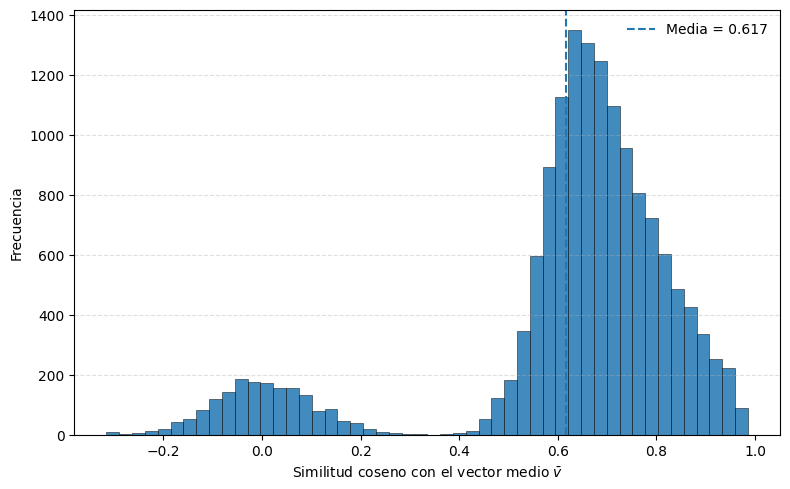

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/histograma_coseno_vector_medio_sgns_wikipedia_tensorflow.pdf


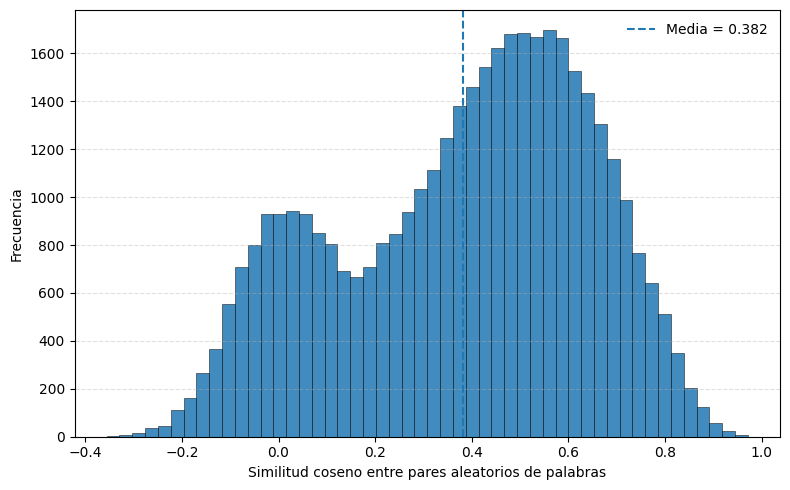

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/histograma_coseno_pares_aleatorios_sgns_wikipedia_tensorflow.pdf

Términos ausentes en el vocabulario:
['lol']

Coordenadas PCA de términos y vector medio:


,termino,PC1,PC2,tipo
0,good,-0.146293,0.404193,termino
1,great,0.184607,-0.023075,termino
2,happy,-0.039837,-0.004353,termino
3,love,0.668283,0.711983,termino
4,perfect,-0.201166,0.580118,termino
5,bad,-0.321279,0.411228,termino
6,sad,1.300086,-0.130552,termino
7,hate,-0.487190,0.583928,termino
8,awful,-0.254571,-0.167367,termino
9,sucks,-1.111485,-1.897191,termino


Tabla guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/tablas/coordenadas_terminos_y_vector_medio_sgns_wikipedia_tensorflow.csv


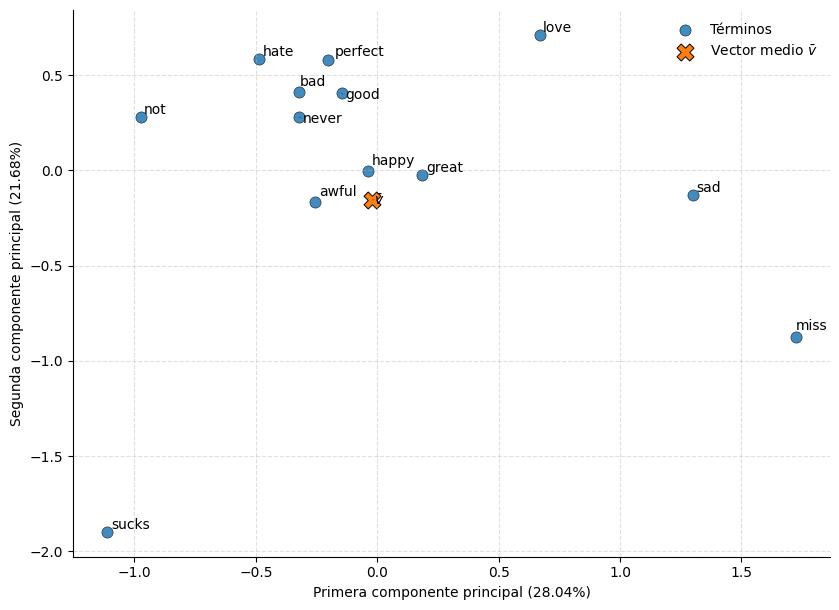

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/pca_terminos_y_vector_medio_sgns_wikipedia_tensorflow.pdf

Resumen palabra-contexto:


,media_producto_vw_uw_alineado,mediana_producto_vw_uw_alineado,media_producto_vw_uc_aleatorio,mediana_producto_vw_uc_aleatorio,porcentaje_productos_aleatorios_negativos,media_coseno_vw_uw_alineado,media_coseno_vw_uc_aleatorio,porcentaje_cosenos_aleatorios_negativos
0,-0.08357,-0.000114,-2.766336,-2.225545,92.635,-0.053663,-0.43227,92.635


Tabla guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/tablas/resumen_palabra_contexto_sgns_wikipedia_tensorflow.csv


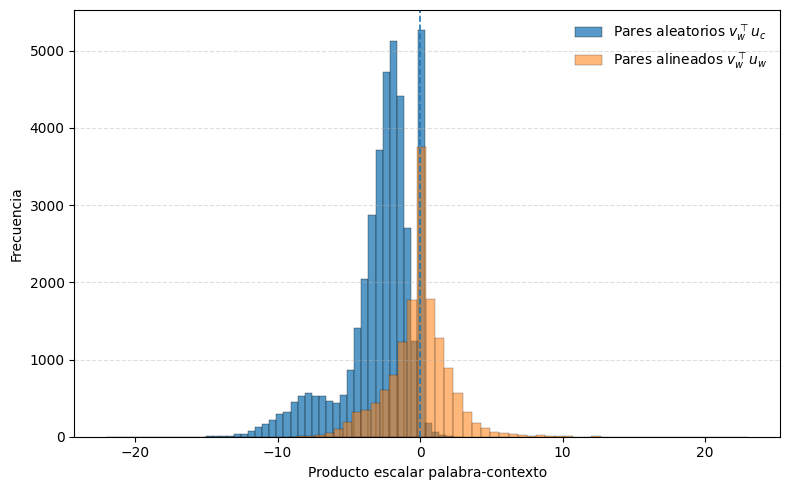

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/histograma_productos_palabra_contexto_sgns_wikipedia_tensorflow.pdf


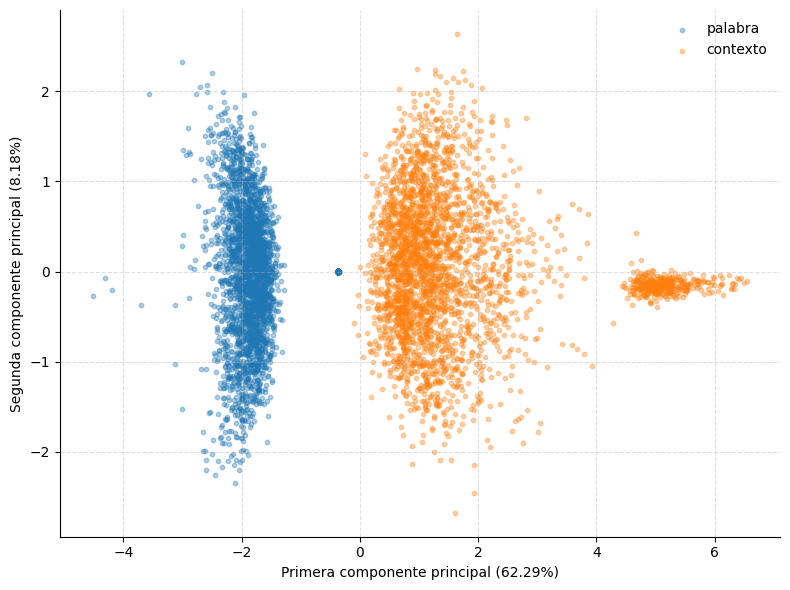

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/pca_vectores_palabra_contexto_sgns_wikipedia_tensorflow.pdf

Resumen pares positivos y negativos:


,n_pares_positivos,n_pares_negativos,media_score_positivo,mediana_score_positivo,media_score_negativo,mediana_score_negativo,porcentaje_scores_positivos_mayores_que_0,porcentaje_scores_negativos_menores_que_0
0,50000,250000,-0.561446,-0.802887,-2.470391,-2.269705,26.332,98.3328


Tabla guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/tablas/resumen_scores_positivos_negativos_sgns_wikipedia_tensorflow.csv


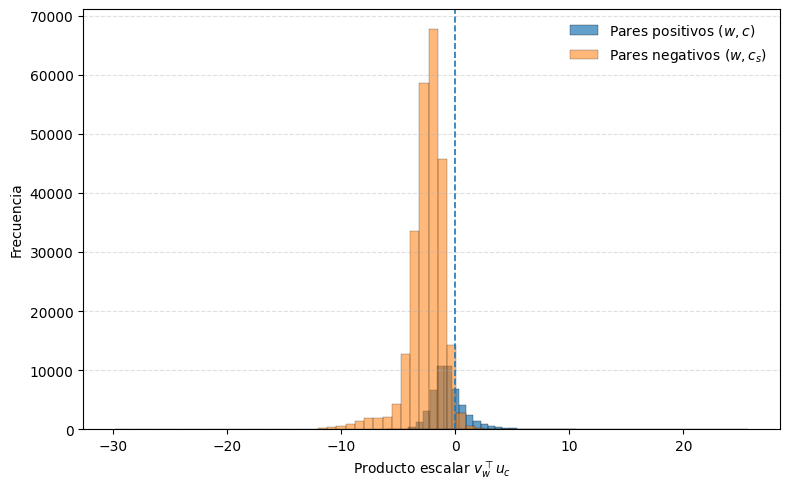

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/histograma_scores_positivos_negativos_sgns_wikipedia_tensorflow.pdf

Términos ausentes en el vocabulario:
['lol']

Matriz de similitud coseno entre términos:


,good,great,happy,love,perfect,bad,sad,hate,awful,sucks,not,never,miss
good,1.000000,0.469642,0.719535,0.652768,0.717889,0.745296,0.487663,0.688414,0.670027,0.446199,0.657481,0.743307,0.448641
great,0.469642,1.000000,0.672554,0.484722,0.369167,0.416908,0.485691,0.500693,0.581081,0.400197,0.259973,0.455536,0.395978
happy,0.719535,0.672554,1.000000,0.690000,0.586360,0.703124,0.536628,0.712279,0.735529,0.586897,0.612859,0.766718,0.559952
love,0.652768,0.484722,0.690000,1.000000,0.575492,0.627276,0.638928,0.609719,0.541141,0.271562,0.370730,0.596760,0.508473
perfect,0.717889,0.369167,0.586360,0.575492,1.000000,0.621290,0.440485,0.602089,0.693266,0.364815,0.621673,0.720383,0.388480
bad,0.745296,0.416908,0.703124,0.627276,0.621290,1.000000,0.407802,0.720855,0.585041,0.468842,0.689182,0.685634,0.388989
sad,0.487663,0.485691,0.536628,0.638928,0.440485,0.407802,1.000000,0.318823,0.496701,0.276010,0.143158,0.379135,0.688477
hate,0.688414,0.500693,0.712279,0.609719,0.602089,0.720855,0.318823,1.000000,0.665683,0.430031,0.673109,0.736221,0.389183
awful,0.670027,0.581081,0.735529,0.541141,0.693266,0.585041,0.496701,0.665683,1.000000,0.658274,0.692922,0.748901,0.516867
sucks,0.446199,0.400197,0.586897,0.271562,0.364815,0.468842,0.276010,0.430031,0.658274,1.000000,0.501562,0.509319,0.357114


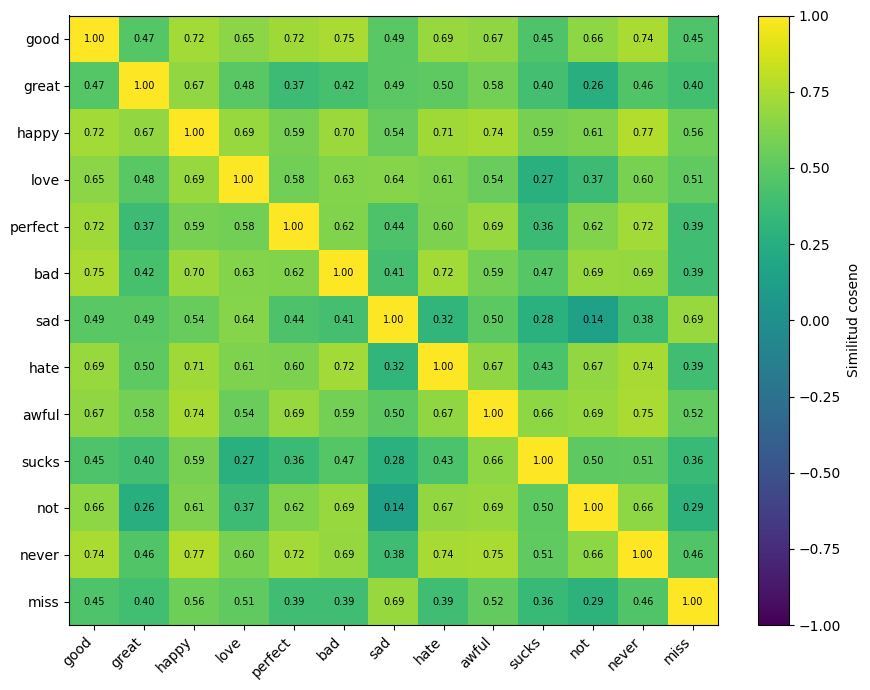

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/heatmap_similitud_terminos_sgns_wikipedia_tensorflow.pdf
Tabla guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/tablas/coordenadas_terminos_sgns_wikipedia_tensorflow.csv


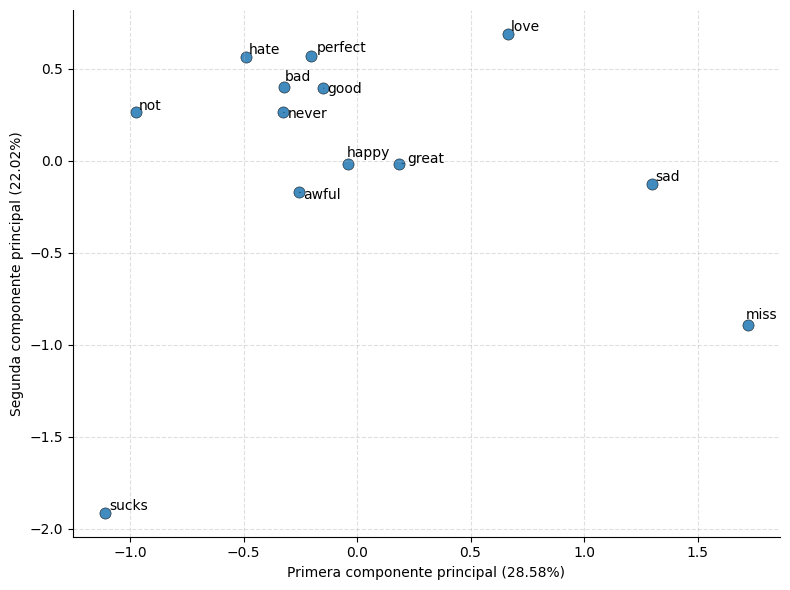

Figura guardada en: /content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras/pca_terminos_sgns_wikipedia_tensorflow.pdf

Análisis geométrico finalizado.
Figuras guardadas en:
/content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/figuras

Tablas guardadas en:
/content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/tablas

Arrays guardados en:
/content/drive/MyDrive/SGNS_Wikipedia/resultados_geometria_sgns_wikipedia_tensorflow/arrays


In [ ]:
# ==============================================================================
# GEOMETRIC ANALYSIS OF SGNS EMBEDDINGS TRAINED ON WIKIPEDIA
# Adapted to the manually implemented Skip-gram model trained with TensorFlow/Keras
# ==============================================================================

# This code must be run AFTER SGNS training on text8/Wikipedia,
# that is, after obtaining:
#
#   E_embeddings : center-word embedding matrix, v_w
#   U_embeddings : context embedding matrix, u_c
#   stoi         : word -> index dictionary
#   itos         : index -> word dictionary
#
# Optionally, if the following variables are also available:
#   centers_train, contexts_train, noise_dist
# the dot products of real positive and negative pairs will also be analyzed.

# ==============================================================================
# 0. INSTALLATION AND IMPORTS
# ==============================================================================

import sys
import subprocess

try:
    from adjustText import adjust_text
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "adjustText"
    ])
    from adjustText import adjust_text

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA


# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

# Main folder used in the second code block
DRIVE_DIR = Path("/content/drive/MyDrive/SGNS_Wikipedia")

# Folder where the geometric-analysis results will be saved
OUTPUT_DIR = DRIVE_DIR / "resultados_geometria_sgns_wikipedia_tensorflow"
FIGURES_DIR = OUTPUT_DIR / "figuras"
TABLES_DIR = OUTPUT_DIR / "tablas"
ARRAYS_DIR = OUTPUT_DIR / "arrays"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
ARRAYS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# Maximum number of words used in the global analysis.
# If the vocabulary is smaller, all words are used.
N_MUESTRA_VOCABULARIO = 15000

# Number of random pairs used to estimate similarity distributions.
N_PARES_COSENO = 40000

# Number of points used for the joint PCA of word and context vectors.
N_PCA_PALABRA_CONTEXTO = 3000

# Terms used in the local analysis.
terminos_interes = [
    "good", "great", "happy", "love", "perfect",
    "bad", "sad", "hate", "awful", "sucks",
    "not", "never", "lol", "miss"
]


# ==============================================================================
# 2. LOAD MATRICES FROM THE TRAINED MODEL
# ==============================================================================

def recuperar_embeddings_y_vocabulario():
    """
    Loads matrices E and U together with the vocabulary.

    Priority:
    1. Use variables already available in memory: E_embeddings, U_embeddings, stoi, itos.
    2. If they are unavailable, attempt to load them from disk.
    """

    global E_embeddings, U_embeddings, stoi, itos

    ruta_E = ARRAYS_DIR / "E_embeddings.npy"
    ruta_U = ARRAYS_DIR / "U_embeddings.npy"
    ruta_vocab = ARRAYS_DIR / "vocabulario.txt"

    variables_en_memoria = (
        "E_embeddings" in globals()
        and "U_embeddings" in globals()
        and "stoi" in globals()
        and "itos" in globals()
    )

    if variables_en_memoria:
        print("Se han encontrado E_embeddings, U_embeddings, stoi e itos en memoria.")

        E = np.asarray(E_embeddings, dtype=np.float64)
        U = np.asarray(U_embeddings, dtype=np.float64)

        # Build the vocabulary ordered by index
        vocab_size = E.shape[0]
        vocabulario = [itos[i] for i in range(vocab_size)]

        # Save a copy for reuse in future runs
        np.save(ruta_E, E)
        np.save(ruta_U, U)

        with open(ruta_vocab, "w", encoding="utf-8") as f:
            for palabra in vocabulario:
                f.write(palabra + "\n")

        print("Se han guardado las matrices y el vocabulario en:")
        print(ARRAYS_DIR)

        return E, U, vocabulario

    else:
        print("No se han encontrado las variables en memoria.")
        print("Intentando cargar matrices y vocabulario desde disco...")

        if not ruta_E.exists() or not ruta_U.exists() or not ruta_vocab.exists():
            raise FileNotFoundError(
                "No se han encontrado E_embeddings, U_embeddings, stoi e itos en memoria "
                "ni tampoco las matrices guardadas en disco. Ejecuta primero el código "
                "de entrenamiento SG-NS sobre Wikipedia/text8."
            )

        E = np.load(ruta_E)
        U = np.load(ruta_U)

        with open(ruta_vocab, "r", encoding="utf-8") as f:
            vocabulario = [line.strip() for line in f if line.strip()]

        stoi = {palabra: i for i, palabra in enumerate(vocabulario)}
        itos = {i: palabra for palabra, i in stoi.items()}

        print("Matrices y vocabulario cargados desde disco.")
        print("Ruta:", ARRAYS_DIR)

        return E.astype(np.float64), U.astype(np.float64), vocabulario


E, U, vocabulario = recuperar_embeddings_y_vocabulario()

print("\nForma de E, embeddings de palabra v_w:", E.shape)
print("Forma de U, embeddings de contexto u_c:", U.shape)
print("Tamaño del vocabulario:", len(vocabulario))


# ==============================================================================
# 3. HELPER FUNCTIONS
# ==============================================================================

def normalizar_filas(X, eps=1e-12):
    """
    Normalizes each row of a matrix so cosine similarities can be computed.
    """

    normas = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(normas, eps)


def obtener_muestra_indices(vocab_size, n_muestra=None, random_state=42):
    """
    Returns indices for a random sample from the vocabulary.
    """

    if n_muestra is None or vocab_size <= n_muestra:
        return np.arange(vocab_size)

    rng = np.random.default_rng(random_state)
    return rng.choice(vocab_size, size=n_muestra, replace=False)


def guardar_dataframe(df, ruta):
    ruta = Path(ruta)
    ruta.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(ruta, index=False, encoding="utf-8")
    print("Tabla guardada en:", ruta)


# ==============================================================================
# 4. MEAN-VECTOR AND GLOBAL-CONCENTRATION ANALYSIS
# ==============================================================================

def analizar_cono_embeddings(
    E,
    vocabulario,
    n_muestra=N_MUESTRA_VOCABULARIO,
    n_pares=N_PARES_COSENO,
    random_state=RANDOM_STATE
):
    """
    Analiza si los embeddings de palabra v_w se concentran en torno a una dirección común.

    Se calcula:
    - vector medio \\bar{v};
    - producto escalar v_w^T \\bar{v};
    - similitud coseno entre v_w y \\bar{v};
    - distribución de similitudes coseno entre pares aleatorios de palabras.
    """

    vocab_size = E.shape[0]

    indices = obtener_muestra_indices(
        vocab_size=vocab_size,
        n_muestra=n_muestra,
        random_state=random_state
    )

    E_muestra = E[indices]
    vocab_muestra = [vocabulario[i] for i in indices]

    E_norm = normalizar_filas(E_muestra)

    # Mean embedding vector
    v_barra = E_muestra.mean(axis=0)
    v_barra_norm = v_barra / np.linalg.norm(v_barra)

    # Dot product and cosine similarity with the mean vector
    productos_con_media = E_muestra @ v_barra
    cosenos_con_media = E_norm @ v_barra_norm

    porcentaje_productos_positivos = np.mean(productos_con_media > 0) * 100
    porcentaje_cosenos_positivos = np.mean(cosenos_con_media > 0) * 100

    # Cosine similarity between random word pairs
    rng = np.random.default_rng(random_state)

    idx_i = rng.integers(0, E_norm.shape[0], size=n_pares)
    idx_j = rng.integers(0, E_norm.shape[0], size=n_pares)

    mascara = idx_i != idx_j
    idx_i = idx_i[mascara]
    idx_j = idx_j[mascara]

    cosenos_pares = np.sum(E_norm[idx_i] * E_norm[idx_j], axis=1)

    resumen = pd.DataFrame([{
        "modelo": "SG-NS Wikipedia TensorFlow",
        "n_palabras_analizadas": len(vocab_muestra),
        "dimension_embedding": E.shape[1],
        "norma_vector_medio": np.linalg.norm(v_barra),
        "media_producto_con_vector_medio": np.mean(productos_con_media),
        "mediana_producto_con_vector_medio": np.median(productos_con_media),
        "porcentaje_productos_positivos_con_media": porcentaje_productos_positivos,
        "media_coseno_con_vector_medio": np.mean(cosenos_con_media),
        "mediana_coseno_con_vector_medio": np.median(cosenos_con_media),
        "std_coseno_con_vector_medio": np.std(cosenos_con_media),
        "porcentaje_cosenos_positivos_con_media": porcentaje_cosenos_positivos,
        "media_coseno_pares_aleatorios": np.mean(cosenos_pares),
        "mediana_coseno_pares_aleatorios": np.median(cosenos_pares),
        "std_coseno_pares_aleatorios": np.std(cosenos_pares)
    }])

    print("\nResumen geométrico global:")
    display(resumen)

    guardar_dataframe(
        resumen,
        TABLES_DIR / "resumen_geometria_sgns_wikipedia_tensorflow.csv"
    )

    df_cosenos_media = pd.DataFrame({
        "palabra": vocab_muestra,
        "producto_con_vector_medio": productos_con_media,
        "coseno_con_vector_medio": cosenos_con_media
    })

    guardar_dataframe(
        df_cosenos_media,
        TABLES_DIR / "coseno_palabras_vector_medio_sgns_wikipedia_tensorflow.csv"
    )

    # --------------------------------------------------------------------------
    # Histogram of cosine similarities with the mean vector
    # --------------------------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.hist(
        cosenos_con_media,
        bins=50,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4
    )

    plt.axvline(
        np.mean(cosenos_con_media),
        linestyle="--",
        linewidth=1.5,
        label=f"Media = {np.mean(cosenos_con_media):.3f}"
    )

    plt.xlabel(r"Similitud coseno con el vector medio $\bar{v}$")
    plt.ylabel("Frecuencia")
    plt.legend(frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "histograma_coseno_vector_medio_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    # --------------------------------------------------------------------------
    # Histogram of cosine similarities between random word pairs
    # --------------------------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.hist(
        cosenos_pares,
        bins=50,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4
    )

    plt.axvline(
        np.mean(cosenos_pares),
        linestyle="--",
        linewidth=1.5,
        label=f"Media = {np.mean(cosenos_pares):.3f}"
    )

    plt.xlabel("Similitud coseno entre pares aleatorios de palabras")
    plt.ylabel("Frecuencia")
    plt.legend(frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "histograma_coseno_pares_aleatorios_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    return resumen, df_cosenos_media, v_barra, cosenos_pares


# ==============================================================================
# 5. PCA OF SELECTED TERMS AND THE MEAN VECTOR
# ==============================================================================

def proyectar_terminos_y_vector_medio(
    E,
    vocabulario,
    stoi,
    terminos,
    random_state=RANDOM_STATE
):
    """
    Proyecta mediante PCA:
    - términos seleccionados;
    - vector medio \\bar{v}.

    Esta visualización permite comprobar si las palabras se organizan alrededor
    de una dirección global dominante.
    """

    terminos_validos = [t for t in terminos if t in stoi]
    terminos_ausentes = [t for t in terminos if t not in stoi]

    if len(terminos_ausentes) > 0:
        print("\nTérminos ausentes en el vocabulario:")
        print(terminos_ausentes)

    if len(terminos_validos) < 2:
        raise ValueError("Se necesitan al menos dos términos presentes en el vocabulario.")

    indices_terminos = [stoi[t] for t in terminos_validos]

    X_terminos = E[indices_terminos]

    v_barra = E.mean(axis=0)

    # Add the mean vector as an additional point
    etiquetas = terminos_validos + [r"$\bar{v}$"]
    X_plot = np.vstack([X_terminos, v_barra.reshape(1, -1)])

    pca = PCA(n_components=2, random_state=random_state)
    X_2d = pca.fit_transform(X_plot)

    varianza = pca.explained_variance_ratio_

    df_coords = pd.DataFrame({
        "termino": etiquetas,
        "PC1": X_2d[:, 0],
        "PC2": X_2d[:, 1],
        "tipo": ["termino"] * len(terminos_validos) + ["vector_medio"]
    })

    print("\nCoordenadas PCA de términos y vector medio:")
    display(df_coords)

    guardar_dataframe(
        df_coords,
        TABLES_DIR / "coordenadas_terminos_y_vector_medio_sgns_wikipedia_tensorflow.csv"
    )

    plt.figure(figsize=(8.5, 6.2))
    ax = plt.gca()

    ax.scatter(
        X_2d[:-1, 0],
        X_2d[:-1, 1],
        s=65,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
        label="Términos"
    )

    ax.scatter(
        X_2d[-1, 0],
        X_2d[-1, 1],
        s=150,
        marker="X",
        edgecolor="black",
        linewidth=0.7,
        label=r"Vector medio $\bar{v}$"
    )

    texts = []

    for i, etiqueta in enumerate(etiquetas):
        texts.append(
            ax.text(
                X_2d[i, 0],
                X_2d[i, 1],
                etiqueta,
                fontsize=10
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.5,
            alpha=0.5
        )
    )

    ax.set_xlabel(f"Primera componente principal ({varianza[0] * 100:.2f}%)")
    ax.set_ylabel(f"Segunda componente principal ({varianza[1] * 100:.2f}%)")

    ax.grid(axis="both", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "pca_terminos_y_vector_medio_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    return df_coords, pca


# ==============================================================================
# 6. ANALYSIS OF WORD AND CONTEXT VECTORS
# ==============================================================================

def analizar_vectores_palabra_y_contexto(
    E,
    U,
    vocabulario,
    n_muestra=N_MUESTRA_VOCABULARIO,
    n_pares=N_PARES_COSENO,
    random_state=RANDOM_STATE
):
    """
    Analyzes the geometric relationship between:
    - E: center-word vectors, v_w;
    - U: context vectors, u_c.

    The function computes:
    - the dot product between v_w and u_w for the same word;
    - the dot product between v_w and u_c for random pairs;
    - the percentage of negative dot products;
    - a joint PCA of word and context vectors.
    """

    vocab_size = E.shape[0]

    indices = obtener_muestra_indices(
        vocab_size=vocab_size,
        n_muestra=n_muestra,
        random_state=random_state
    )

    V = E[indices]
    C = U[indices]

    V_norm = normalizar_filas(V)
    C_norm = normalizar_filas(C)

    rng = np.random.default_rng(random_state)

    # Aligned pairs: the same word used as center and context
    productos_alineados = np.sum(V * C, axis=1)
    cosenos_alineados = np.sum(V_norm * C_norm, axis=1)

    # Random word-context pairs
    idx_v = rng.integers(0, V.shape[0], size=n_pares)
    idx_c = rng.integers(0, C.shape[0], size=n_pares)

    productos_aleatorios = np.sum(V[idx_v] * C[idx_c], axis=1)
    cosenos_aleatorios = np.sum(V_norm[idx_v] * C_norm[idx_c], axis=1)

    resumen = pd.DataFrame([{
        "media_producto_vw_uw_alineado": np.mean(productos_alineados),
        "mediana_producto_vw_uw_alineado": np.median(productos_alineados),
        "media_producto_vw_uc_aleatorio": np.mean(productos_aleatorios),
        "mediana_producto_vw_uc_aleatorio": np.median(productos_aleatorios),
        "porcentaje_productos_aleatorios_negativos": np.mean(productos_aleatorios < 0) * 100,
        "media_coseno_vw_uw_alineado": np.mean(cosenos_alineados),
        "media_coseno_vw_uc_aleatorio": np.mean(cosenos_aleatorios),
        "porcentaje_cosenos_aleatorios_negativos": np.mean(cosenos_aleatorios < 0) * 100
    }])

    print("\nResumen palabra-contexto:")
    display(resumen)

    guardar_dataframe(
        resumen,
        TABLES_DIR / "resumen_palabra_contexto_sgns_wikipedia_tensorflow.csv"
    )

    # --------------------------------------------------------------------------
    # Histogram of word-context dot products
    # --------------------------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.hist(
        productos_aleatorios,
        bins=50,
        alpha=0.75,
        label=r"Pares aleatorios $v_w^\top u_c$",
        edgecolor="black",
        linewidth=0.3
    )

    plt.hist(
        productos_alineados,
        bins=50,
        alpha=0.55,
        label=r"Pares alineados $v_w^\top u_w$",
        edgecolor="black",
        linewidth=0.3
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1.2
    )

    plt.xlabel(r"Producto escalar palabra-contexto")
    plt.ylabel("Frecuencia")
    plt.legend(frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "histograma_productos_palabra_contexto_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    # --------------------------------------------------------------------------
    # Joint PCA of word and context vectors
    # --------------------------------------------------------------------------

    n_pca = min(N_PCA_PALABRA_CONTEXTO, V.shape[0])
    idx_pca = rng.choice(V.shape[0], size=n_pca, replace=False)

    X_conjunto = np.vstack([V[idx_pca], C[idx_pca]])
    tipos = np.array(["palabra"] * n_pca + ["contexto"] * n_pca)

    pca = PCA(n_components=2, random_state=random_state)
    X_2d = pca.fit_transform(X_conjunto)

    varianza = pca.explained_variance_ratio_

    plt.figure(figsize=(8, 6))
    ax = plt.gca()

    for tipo in ["palabra", "contexto"]:
        mascara = tipos == tipo

        ax.scatter(
            X_2d[mascara, 0],
            X_2d[mascara, 1],
            s=10,
            alpha=0.35,
            label=tipo
        )

    ax.set_xlabel(f"Primera componente principal ({varianza[0] * 100:.2f}%)")
    ax.set_ylabel(f"Segunda componente principal ({varianza[1] * 100:.2f}%)")

    ax.grid(axis="both", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "pca_vectores_palabra_contexto_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    return resumen


# ==============================================================================
# 7. ANALYSIS OF POSITIVE AND NEGATIVE TRAINING PAIRS
# ==============================================================================

def analizar_pares_positivos_negativos_reales(
    E,
    U,
    centers_train,
    contexts_train,
    noise_dist,
    n_pares=50000,
    num_negative=5,
    random_state=RANDOM_STATE
):
    """
    Directly analyzes negative sampling using real positive training pairs
    and negative contexts sampled from the noise distribution.

    This makes it possible to observe that:
    - observed pairs (w, c) tend to have larger dot products;
    - negative pairs tend to shift toward smaller dot products.
    """

    rng = np.random.default_rng(random_state)

    n_total = len(centers_train)
    n = min(n_pares, n_total)

    idx = rng.choice(n_total, size=n, replace=False)

    centers_sample = centers_train[idx]
    contexts_sample = contexts_train[idx]

    # Positive pairs
    v_centers = E[centers_sample]
    u_pos = U[contexts_sample]

    scores_positivos = np.sum(v_centers * u_pos, axis=1)

    # Negative pairs
    if hasattr(noise_dist, "numpy"):
        p_noise = noise_dist.numpy()
    else:
        p_noise = np.asarray(noise_dist, dtype=np.float64)

    p_noise = p_noise / p_noise.sum()

    negative_contexts = rng.choice(
        np.arange(E.shape[0]),
        size=n * num_negative,
        replace=True,
        p=p_noise
    )

    negative_centers = np.repeat(centers_sample, num_negative)

    v_neg_centers = E[negative_centers]
    u_neg = U[negative_contexts]

    scores_negativos = np.sum(v_neg_centers * u_neg, axis=1)

    resumen = pd.DataFrame([{
        "n_pares_positivos": len(scores_positivos),
        "n_pares_negativos": len(scores_negativos),
        "media_score_positivo": np.mean(scores_positivos),
        "mediana_score_positivo": np.median(scores_positivos),
        "media_score_negativo": np.mean(scores_negativos),
        "mediana_score_negativo": np.median(scores_negativos),
        "porcentaje_scores_positivos_mayores_que_0": np.mean(scores_positivos > 0) * 100,
        "porcentaje_scores_negativos_menores_que_0": np.mean(scores_negativos < 0) * 100
    }])

    print("\nResumen pares positivos y negativos:")
    display(resumen)

    guardar_dataframe(
        resumen,
        TABLES_DIR / "resumen_scores_positivos_negativos_sgns_wikipedia_tensorflow.csv"
    )

    # --------------------------------------------------------------------------
    # Histogram of positive and negative dot products
    # --------------------------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.hist(
        scores_positivos,
        bins=50,
        alpha=0.70,
        label=r"Pares positivos $(w,c)$",
        edgecolor="black",
        linewidth=0.3
    )

    plt.hist(
        scores_negativos,
        bins=50,
        alpha=0.55,
        label=r"Pares negativos $(w,c_s)$",
        edgecolor="black",
        linewidth=0.3
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1.2
    )

    plt.xlabel(r"Producto escalar $v_w^\top u_c$")
    plt.ylabel("Frecuencia")
    plt.legend(frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "histograma_scores_positivos_negativos_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    return resumen, scores_positivos, scores_negativos


# ==============================================================================
# 8. LOCAL COSINE-SIMILARITY ANALYSIS BETWEEN TERMS
# ==============================================================================

def analizar_similitud_terminos(
    E,
    stoi,
    terminos,
    random_state=RANDOM_STATE
):
    """
    Computes the cosine-similarity matrix for selected terms and their PCA projection.
    This connects local semantic proximity with the global geometry of the embedding space.
    """

    terminos_validos = [t for t in terminos if t in stoi]
    terminos_ausentes = [t for t in terminos if t not in stoi]

    if len(terminos_ausentes) > 0:
        print("\nTérminos ausentes en el vocabulario:")
        print(terminos_ausentes)

    indices = [stoi[t] for t in terminos_validos]
    X = E[indices]

    X_norm = normalizar_filas(X)

    matriz_similitud = X_norm @ X_norm.T

    df_sim = pd.DataFrame(
        matriz_similitud,
        index=terminos_validos,
        columns=terminos_validos
    )

    print("\nMatriz de similitud coseno entre términos:")
    display(df_sim)

    df_sim.to_csv(
        TABLES_DIR / "matriz_similitud_terminos_sgns_wikipedia_tensorflow.csv",
        encoding="utf-8"
    )

    # --------------------------------------------------------------------------
    # Cosine-similarity heatmap
    # --------------------------------------------------------------------------

    plt.figure(figsize=(9, 7))
    ax = plt.gca()

    im = ax.imshow(
        matriz_similitud,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    ax.set_xticks(np.arange(len(terminos_validos)))
    ax.set_yticks(np.arange(len(terminos_validos)))
    ax.set_xticklabels(terminos_validos, rotation=45, ha="right")
    ax.set_yticklabels(terminos_validos)

    for i in range(len(terminos_validos)):
        for j in range(len(terminos_validos)):
            ax.text(
                j,
                i,
                f"{matriz_similitud[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

    cbar = plt.colorbar(im)
    cbar.set_label("Similitud coseno")

    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "heatmap_similitud_terminos_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    # --------------------------------------------------------------------------
    # PCA of selected terms
    # --------------------------------------------------------------------------

    pca = PCA(n_components=2, random_state=random_state)
    X_2d = pca.fit_transform(X)

    varianza = pca.explained_variance_ratio_

    df_coords = pd.DataFrame({
        "termino": terminos_validos,
        "PC1": X_2d[:, 0],
        "PC2": X_2d[:, 1]
    })

    guardar_dataframe(
        df_coords,
        TABLES_DIR / "coordenadas_terminos_sgns_wikipedia_tensorflow.csv"
    )

    plt.figure(figsize=(8, 6))
    ax = plt.gca()

    ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        s=65,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4
    )

    texts = []

    for i, termino in enumerate(terminos_validos):
        texts.append(
            ax.text(
                X_2d[i, 0],
                X_2d[i, 1],
                termino,
                fontsize=10
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.5,
            alpha=0.5
        )
    )

    ax.set_xlabel(f"Primera componente principal ({varianza[0] * 100:.2f}%)")
    ax.set_ylabel(f"Segunda componente principal ({varianza[1] * 100:.2f}%)")

    ax.grid(axis="both", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    ruta_figura = FIGURES_DIR / "pca_terminos_sgns_wikipedia_tensorflow.pdf"
    plt.savefig(ruta_figura, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", ruta_figura)

    return df_sim, df_coords


# ==============================================================================
# 9. RUN THE COMPLETE ANALYSIS
# ==============================================================================

# ------------------------------------------------------------------------------
# 9.1. Global concentration of embeddings around the mean vector
# ------------------------------------------------------------------------------

df_resumen_geo, df_cosenos_media, v_barra, cosenos_pares = analizar_cono_embeddings(
    E=E,
    vocabulario=vocabulario,
    n_muestra=N_MUESTRA_VOCABULARIO,
    n_pares=N_PARES_COSENO,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------------------------
# 9.2. PCA of selected terms together with the mean vector
# ------------------------------------------------------------------------------

df_coords_media, pca_media = proyectar_terminos_y_vector_medio(
    E=E,
    vocabulario=vocabulario,
    stoi=stoi,
    terminos=terminos_interes,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------------------------
# 9.3. Relationship between word vectors v_w and context vectors u_c
# ------------------------------------------------------------------------------

df_resumen_contexto = analizar_vectores_palabra_y_contexto(
    E=E,
    U=U,
    vocabulario=vocabulario,
    n_muestra=N_MUESTRA_VOCABULARIO,
    n_pares=N_PARES_COSENO,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------------------------
# 9.4. Analysis of positive and negative pairs when training variables are available
# ------------------------------------------------------------------------------

if (
    "centers_train" in globals()
    and "contexts_train" in globals()
    and "noise_dist" in globals()
):
    resumen_scores, scores_positivos, scores_negativos = analizar_pares_positivos_negativos_reales(
        E=E,
        U=U,
        centers_train=centers_train,
        contexts_train=contexts_train,
        noise_dist=noise_dist,
        n_pares=50000,
        num_negative=5,
        random_state=RANDOM_STATE
    )
else:
    print("\nNo se han encontrado centers_train, contexts_train y noise_dist en memoria.")
    print("Se omite el análisis directo de pares positivos y negativos reales.")


# ------------------------------------------------------------------------------
# 9.5. Cosine similarity and local PCA of selected terms
# ------------------------------------------------------------------------------

df_sim_terminos, df_coords_terminos = analizar_similitud_terminos(
    E=E,
    stoi=stoi,
    terminos=terminos_interes,
    random_state=RANDOM_STATE
)


# ==============================================================================
# 10. FINAL PATH SUMMARY
# ==============================================================================

print("\nAnálisis geométrico finalizado.")
print("Figuras guardadas en:")
print(FIGURES_DIR)

print("\nTablas guardadas en:")
print(TABLES_DIR)

print("\nArrays guardados en:")
print(ARRAYS_DIR)